
<br>
<font>
<!-- <img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" alt="SUT logo" width=300 height=300 align=left class="saturate"> -->
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=200 height=200>
<br>
<font color=0F5298 size=7>
Introduction to Machine Learning <br>
<font color=2565AE size=5>
Electrical Engineering Department <br>
Spring 2026<br>
Dr.Shamsollahi<br>
<font color=3C99D size=5>
CHW3 <br>
<font color=696880 size=4>
<!-- <br> -->


____

*For your questions refer to @MehrshadGoljarian and @Smm236 on Telegram*

<div dir="rtl">

# اطلاعات دانشجو

این سلول را با اطلاعات خودتان کامل کنید. مقدار `seed` باید بر اساس سه رقم آخر شماره دانشجویی ساخته شود.

</div>

In [78]:
student_number = '402102392'
first_name = 'Niloofar'
last_name = 'Mahmoodi'

last_three_digits = int(student_number[-3:].zfill(3))
seed = 1000 + last_three_digits

seed

1392

<div dir="rtl">

# نکات اجرایی مشترک

در این تمرین باید کدها قابل اجرای مجدد باشند. همه انتخاب‌های تصادفی، از جمله مقداردهی اولیه در `K-Means` و انتخاب نمونه آهنگ‌ها از خوشه‌ها، باید با `seed` تعریف‌شده انجام شوند.

در هر بخش علاوه بر کد، یک توضیح کوتاه بر اساس خروجی واقعی خودتان بنویسید. نمودارها باید عنوان و برچسب محور داشته باشند.

</div>

<div dir="rtl">

# سؤال اول: خوشه‌بندی آهنگ‌های اسپاتیفای

هدف این سؤال بررسی این است که آیا می‌توان آهنگ‌های موجود در فایل `spotify.csv` را بر اساس ویژگی‌های مرتبط، در چند گروه معنادار خوشه‌بندی کرد یا خیر.

</div>

<div dir="rtl">

## ۱.۱ خواندن داده و انتخاب ویژگی‌ها

داده را بخوانید. سپس شکل داده، نام ستون‌ها، نوع داده هر ستون و تعداد مقادیر گمشده را نمایش دهید. ستون‌هایی را که برای خوشه‌بندی مناسب نمی‌دانید حذف کنید و فقط نام ترک و ویژگی‌های مرتبط را نگه دارید.

در یک سلول متنی کوتاه توضیح دهید هر ویژگی را چرا نگه داشته یا حذف کرده‌اید.

</div>

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import LabelEncoder

rng = np.random.default_rng(seed)

from IPython.display import display

In [80]:
spotify_path = 'spotify.csv'

df = pd.read_csv(spotify_path)
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [81]:
...

Ellipsis

In [82]:
data_overview = pd.DataFrame({'dtype':df.dtypes.astype(str),'missing_values':df.isna().sum(),'n_unique': df.nunique(dropna=False)})
display(data_overview)
print('Duplicate track_ids :',df.duplicated(subset='track_id').sum())

,dtype,missing_values,n_unique
track_id,str,0,28356
track_name,str,5,23450
track_artist,str,5,10693
track_popularity,int64,0,101
track_album_id,str,0,22545
track_album_name,str,5,19744
track_album_release_date,str,0,4530
playlist_name,str,0,449
playlist_id,str,0,471
playlist_genre,str,0,6


Duplicate track_ids : 4477


In [83]:
df = df.drop_duplicates(subset='track_id').copy().reset_index(drop=True)
df['track_name'] =df['track_name'].fillna('(unknown track)')
df['track_artist']= df['track_artist'].fillna('(unknown artist)')

Feature = ['danceability','energy', 'loudness', 'speechiness','acousticness', 'instrumentalness', 'liveness', 'valence','tempo','duration_ms']

selected_columns = [
    'track_name','track_artist','playlist_genre','playlist_subgenre'
] + Feature

df_selected = df[selected_columns].copy()
df_selected.head()

,track_name,track_artist,playlist_genre,playlist_subgenre,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,pop,dance pop,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,Memories - Dillon Francis Remix,Maroon 5,pop,dance pop,0.726,0.815,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,All the Time - Don Diablo Remix,Zara Larsson,pop,dance pop,0.675,0.931,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,pop,dance pop,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,pop,dance pop,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


<div dir="rtl">

### توضیح انتخاب ویژگی‌ها

| ویژگی | نگه داشته شد / حذف شد | دلیل |
|---|---|---|
| track_name , track_artist | نگه‌ داشته می شود | ضروری هستند ولی در الگوریتم وارد نمی شوند |
| danceability ,energy , loudness, speechiness , acousticness ,    instrumentalness , liveness , valence , tempo,duration_ms | نگه‌ داشته می شود | مستقیما ویژگی‌ های صوتی و ریتم وانرژی و.. آهنگ را توصیف می‌ کنند و استفاده می کنیم تو مدل این ها را |
| playlist_genre, playlist_subgenre | نگه‌ داشته می شود | استفاده از آن‌ ها در آموزش باعث می‌ شود خوشه ها از برچسب‌ هایی که از پیش موجود است تقلید کنند. همچنین LabelEncoder برای ژانر ترتیب مصنوعی ایجاد می‌ کند. |
| track_id ,track_album_id, playlist_id | حذف می شود | شناسه‌ اند و فاصله‌ ی عددی معناداری ندارند |
| نام آلبوم و نام پلی‌ لیست و تاریخ انتشار و نام هنرمند | حذف می شود | پیوستگی زیادی دارند و شباهت صوتی را مستقیما نشان نمی‌ دهند |
| key , mode | حذف می شود | ماهیت دایره ای دارند و استفاده‌ ی مستقیم از اعداد آن‌ ها فاصله‌ ی اقلیدسی گمراه کننده می‌ سازد |
| track_popularity | حذف می شود | ساختار صوتی آهنگ را بیان نمی کند و مفید نیست |

پنج مقدار ناشناخته نام آهنگ با عبارت (unknown track) جایگزین شد. در ویژگی‌ های عددی انتخاب‌ شده مقدار ناشناخته ای وجود نداشت. همچنین ۴۴۷۷ تکرار بر اساس track_id حذف شد تا یک آهنگ به‌ دلیل حضور در چند پلی‌ لیست وزن بیشتری نگیرد.

</div>

<div dir="rtl">

## ۱.۲ استانداردسازی از ابتدا

یک تابع یا کلاس برای استانداردسازی داده‌ها با رفتار مشابه `StandardScaler` پیاده‌سازی کنید. در این بخش نباید از `sklearn.preprocessing.StandardScaler` استفاده شود. اگر انحراف معیار یک ویژگی صفر بود، باید از تقسیم بر صفر جلوگیری شود.

</div>

In [84]:
def fit_standard_scaler(X):
    X =np.asarray(X, dtype=float)
    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0, ddof=0)
    stds_safe= np.where(stds == 0, 1.0, stds)
    return means, stds_safe

def transform_standard_scaler(X, means, stds):
    X =np.asarray(X, dtype=float)
    return (X -means) /stds

def fit_transform_standard_scaler(X):
    means, stds =fit_standard_scaler(X)
    X_scaled= transform_standard_scaler(X, means,stds)
    return X_scaled, means,stds

In [85]:
X = df_selected[Feature].to_numpy(dtype=float)
X_scaled, feature_means, feature_stds =fit_transform_standard_scaler(X)

before_after = pd.DataFrame({'mean_before':X.mean(axis=0),'std_before': X.std(axis=0, ddof=0),'mean_after': X_scaled.mean(axis=0),'std_after': X_scaled.std(axis=0, ddof=0),}, index=Feature)
display(before_after.round(6))

,mean_before,std_before,mean_after,std_after
danceability,0.653372,0.145783,0.0,1.0
energy,0.698388,0.183500,-0.0,1.0
loudness,-6.817696,3.036189,0.0,1.0
speechiness,0.107954,0.102554,0.0,1.0
acousticness,0.177176,0.222799,0.0,1.0
instrumentalness,0.091117,0.232544,-0.0,1.0
liveness,0.190958,0.155892,-0.0,1.0
valence,0.510387,0.234336,-0.0,1.0
tempo,120.956180,26.954084,-0.0,1.0
duration_ms,226575.967026,61077.373816,-0.0,1.0


<div dir="rtl">

### توضیح کوتاه

استانداردسازی در این تمرین مهم است چون : مقیاس ستون ها بسیار متفاوت است. برای نمونه duration_ms در مرتبه ی صدها هزار است در حالی که بسیاری از ویژگی ها بین صفر و یک قرار دارند. بدون استانداردسازی duration_ms در فاصله ی اقلیدسی K-Means و ماتریس کوواریانس PCA غالب می‌ شود. پس از تبدیل  میانگین همه ی ویژگی ها تقریبا صفر و انحراف معیار آن ها تقریبا یک است و هر ویژگی مب تواند که اثر خودشو بذارد.

</div>

<div dir="rtl">

## ۱.۳ کاهش بعد با `PCA` آماده

با استفاده از `PCA` در `sklearn`، داده استانداردشده را به فضای مولفه‌های اصلی ببرید. نمودار واریانس توضیح‌داده‌شده تجمعی را رسم کنید و تعداد مولفه‌های مناسب را با یک آستانه مشخص انتخاب کنید.

</div>

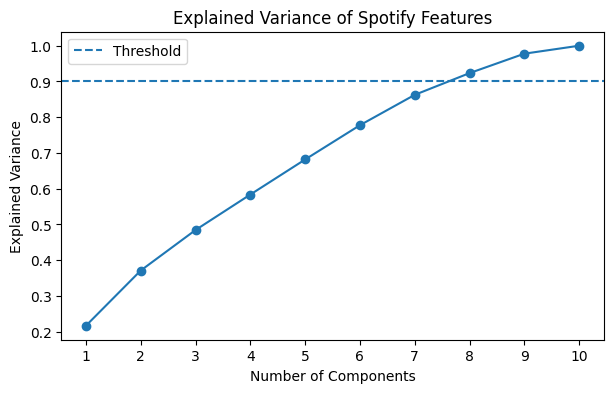

,component,explained_variance_ratio,cumulative_variance
0,1,0.2168,0.2168
1,2,0.1544,0.3712
2,3,0.1133,0.4845
3,4,0.0992,0.5838
4,5,0.0980,0.6818
5,6,0.0959,0.7777
6,7,0.0849,0.8626
7,8,0.0608,0.9234
8,9,0.0543,0.9777
9,10,0.0223,1.0000


In [86]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(cumulative_variance)+ 1), cumulative_variance,marker='o')
plt.axhline(0.9, linestyle='--', label='Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Explained Variance of Spotify Features')
plt.xticks(range(1,len(cumulative_variance)+ 1))
plt.legend()
plt.show()
display(pd.DataFrame({'component': np.arange(1, len(explained_variance_ratio)+ 1),'explained_variance_ratio': explained_variance_ratio,'cumulative_variance': cumulative_variance}).round(4))

In [87]:
variance_threshold = 0.9
n_components = int(np.argmax(cumulative_variance >= variance_threshold)+ 1)

pca = PCA(n_components=n_components, random_state=seed)
X_pca = pca.fit_transform(X_scaled)

print('Number of Selected Components:', n_components)
X_pca.shape

Number of Selected Components: 8


(28356, 8)

<div dir="rtl">

### توضیح انتخاب تعداد مولفه‌ها

تعداد مولفه‌های انتخاب‌شده: 8

دلیل انتخاب: با آستانه ی 90٪، این مؤلفه ها حدود 92٪ واریانس داده ی استاندارد شده را حفظ می کنند. مولفه ی هفتم هنوز فقط حدود 85% را پوشش می داد و مولفه ی نهم پوشش را به حدود 98٪ می رساند. هشت مولفه سازگاری مناسبی بین فشرده سازی و حفظ اطلاعات است و از انتخاب کاملا سلیقه ای جلوگیری می کند.

</div>

<div dir="rtl">

## ۱.۴ پیاده‌سازی `K-Means` از ابتدا

الگوریتم `K-Means` را از ابتدا پیاده‌سازی کنید. تابع شما باید مراکز اولیه را با `seed` انتخاب کند، برچسب‌ها را بر اساس فاصله اقلیدسی تعیین کند، مراکز را به‌روزرسانی کند و مقدار خطای درون‌خوشه‌ای را در هر تکرار ذخیره کند.

</div>

In [88]:
def error_s(X, centroids):
    distances= np.sum(X **2, axis=1, keepdims=True) + np.sum(centroids ** 2, axis=1, keepdims=True).T- 2 * X @ centroids.T
    return np.maximum(distances, 0.0)  

def kmeans_from_scratch(X, k, max_iters=100, tol=1e-4, random_state=None):
    X = np.asarray(X, dtype=float)
    initial =np.random.default_rng(random_state).choice(len(X),size=k, replace=False)
    centroids = X[initial].copy()
    inertia_history = []
    labels =np.full(len(X), -1,dtype=int)
    for _ in range(max_iters):
        distances_sq = error_s(X, centroids)
        labels_new = np.argmin(distances_sq,axis=1)
        inertia_history.append(float(np.sum(distances_sq[np.arange(len(X)), labels_new])))
        centroids_new =centroids.copy()
        min_distances= distances_sq[np.arange(len(X)), labels_new]
        for cluster in range(k):
            cluster_mask = labels_new== cluster
            if np.any(cluster_mask):
                centroids_new[cluster] =X[cluster_mask].mean(axis=0)
            else:
                centroids_new[ cluster] = X[int(np.argmax(min_distances))]

        centroid_shift =np.linalg.norm(centroids_new - centroids)
        changed_label =np.array_equal(labels_new,labels)
        centroids = centroids_new
        labels= labels_new
        if centroid_shift <= tol or changed_label:
            break
    final_distances = error_s(X, centroids)
    labels= np.argmin(final_distances,axis=1)
    final_inertia =float(np.sum(final_distances[np.arange(len(X)), labels]))
    if not np.isclose(inertia_history[-1],final_inertia):
        inertia_history.append(final_inertia)
    return centroids, labels, inertia_history

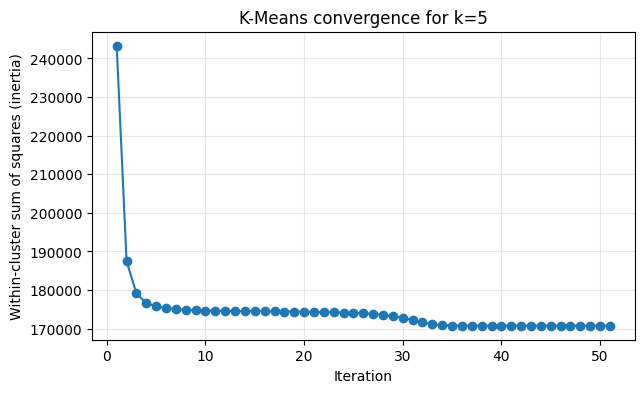

Number of iterations: 51
Final inertia: 170773.74295650967


In [89]:
sample_k = 5
centroids, labels, inertia_history = kmeans_from_scratch(X_pca, k=sample_k, max_iters=100, tol=1e-4, random_state=seed)
plt.figure(figsize=(7,4))
plt.plot(range(1,len(inertia_history) +1), inertia_history,marker='o')
plt.xlabel('Iteration')
plt.ylabel('Within-cluster sum of squares (inertia)')
plt.title(f'K-Means convergence for k={sample_k}')
plt.grid(alpha=0.3)
plt.show()
print('Number of iterations:', len(inertia_history))
print('Final inertia:', inertia_history[-1])

<div dir="rtl">

### تحلیل همگرایی

بر اساس نمودار خطای درون‌خوشه‌ای: برای k=5 مقدار خطای درون‌ خوشه ای در هر تکرار کاهش یافته و پس از حدود ۴۵ تکرار تقریبا ثابت شده است. صعودی نشدن نمودار مطابق انتظار ما از K-Means است چون مرحله ی تخصیص و مرحله ی به روزرسانی مراکز هر دو خطا را کم یا ثابت می کنند. ثابت شدن انتهای منحنی نشان می دهد الگوریتم برای این مقداردهی اولیه همگرا شده است.

</div>

<div dir="rtl">

## ۱.۵ انتخاب تعداد خوشه‌ها

تابع `K-Means` خود را برای `k` از ۳ تا ۱۰ اجرا کنید. برای هر مقدار، `Silhouette Score` و `Davies-Bouldin Index` را محاسبه و نمودارهای مربوط را رسم کنید.

</div>

In [90]:
k_values = list(range(3, 11))

silhouette_scores = []
davies_bouldin_scores = []
kmeans_results = {}

for k in k_values:
    centroids_k, labels_k,history_k= kmeans_from_scratch( X_pca, k=k, max_iters=100, tol=1e-4, random_state=seed)
    silhouette = silhouette_score(X_pca, labels_k,sample_size=5600,random_state=seed)
    davies_bouldin= davies_bouldin_score(X_pca,labels_k)
    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(davies_bouldin)
    kmeans_results[k] ={'centroids': centroids_k,'labels': labels_k,'history': history_k,'silhouette': silhouette, 'davies_bouldin': davies_bouldin}
metrics_table = pd.DataFrame({'k': k_values,'Silhouette Score':silhouette_scores,'Davies-Bouldin Index': davies_bouldin_scores})
display(metrics_table.round(4))

,k,Silhouette Score,Davies-Bouldin Index
0,3,0.1421,2.0772
1,4,0.1411,1.9339
2,5,0.1443,1.7968
3,6,0.1552,1.6235
4,7,0.1398,1.6417
5,8,0.1358,1.6102
6,9,0.1354,1.5950
7,10,0.1347,1.5574


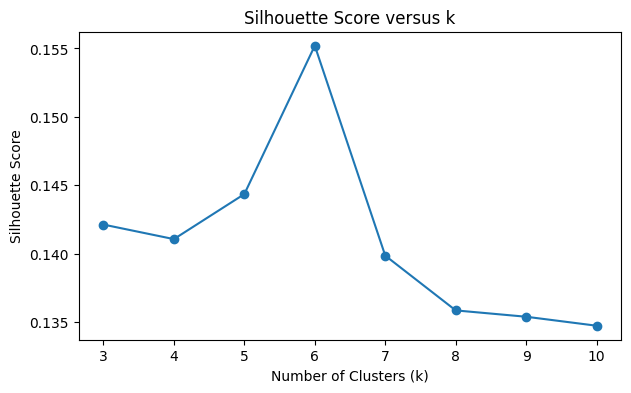

In [91]:
plt.figure(figsize=(7,4))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score versus k')
plt.xticks(k_values)
plt.show()

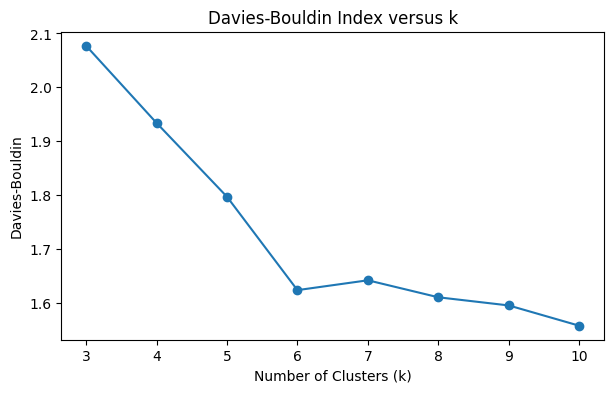

In [92]:
plt.figure(figsize=(7,4))
plt.plot(k_values,davies_bouldin_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin')
plt.title('Davies-Bouldin Index versus k')
plt.show()

In [93]:
best_k_silhouette= k_values[int(np.argmax(silhouette_scores))]
best_k_db =k_values[int(np.argmin(davies_bouldin_scores))]

best_k = best_k_silhouette
centroids =kmeans_results[best_k]['centroids']
final_labels = kmeans_results[best_k]['labels']
inertia_history= kmeans_results[best_k]['history']
print('Best k based on Silhouette:', best_k_silhouette)
print('Best k based on Davies-Bouldin:',best_k_db)
print('Final k:',best_k)

Best k based on Silhouette: 6
Best k based on Davies-Bouldin: 10
Final k: 6


<div dir="rtl">

### توضیح انتخاب `k`

مقدار نهایی `k`: 6

دلیل انتخاب: معیار Silhouette در k=6 بیشترین مقدار را دارد در حالی که Davies-Bouldin کمترین مقدار را در k=10 می دهد. مقدار نهایی k=6 انتخاب شد چون برتری آن در Silhouette نسبت به گزینه های دیگر واضح‌ تر است و سه خوشه تفسیر ساده تری به عنوان گروه های کلی صوتی دارند

اگر دو معیار پاسخ متفاوتی داده‌اند، توضیح دهید کدام معیار را ترجیح داده‌اید و چرا.
 Silhouette هم جدایی و هم انسجام هر نمونه را می‌ سنجد اما Davies-Bouldin بر نسبت پراکندگی درون‌ خوشه ای به فاصله مراکز تکیه دارد و گاهی تعداد خوشه بیشتر را ترجیح می‌ دهد. مقدار نسبتا پایین Silhouette همچنین نشان می‌ دهد مرز گروه های موسیقی کاملا جدا نیست و هم‌ پوشانی قابل‌ توجهی وجود دارد.

</div>

<div dir="rtl">

## ۱.۶ تحلیل خوشه‌ها و نمایش دوبعدی

برای مقدار `k` انتخاب‌شده، داده‌ها را با دو مولفه اول `PCA` روی نمودار دوبعدی رسم کنید. سپس از هر خوشه دو آهنگ را با استفاده از `seed` انتخاب کنید و فاصله آن‌ها را گزارش دهید.

</div>

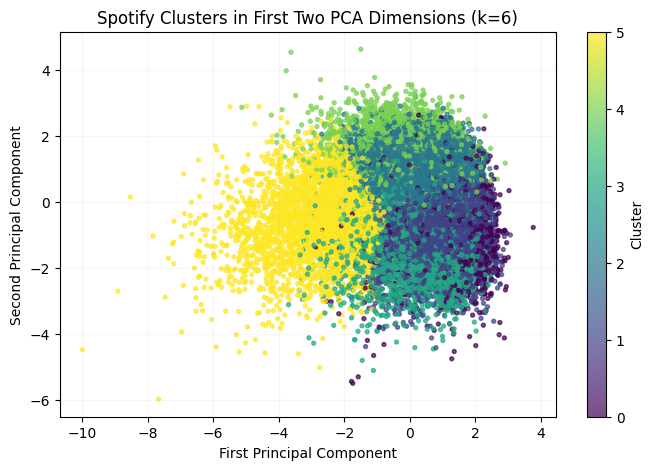

In [94]:
plt.figure(figsize=(8,5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],c=final_labels,s=8, alpha=0.7)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'Spotify Clusters in First Two PCA Dimensions (k={best_k})')
plt.colorbar(scatter,label='Cluster')
plt.grid(alpha=0.1)
plt.show()

In [95]:
track_names = df_selected['track_name'].to_numpy()
track_artists = df_selected['track_artist'].to_numpy()

cluster_profile = (pd.DataFrame(X, columns=Feature).assign(cluster=final_labels).groupby('cluster').mean())
print('Cluster sizes and mean features in original units:')
display((pd.Series(final_labels).value_counts().sort_index().rename('size')).to_frame())
display(cluster_profile.round(4))
print('Standardized cluster profiles (positive sign means above overall mean):')
display(((cluster_profile -feature_means) /feature_stds).round(3))

for cluster in range(best_k):
    genre_share =(df_selected.loc[final_labels ==cluster, 'playlist_genre'].value_counts(normalize=True).head(5).rename('share'))
    print(f'Most frequent genres for cluster {cluster}:')
    display(genre_share.to_frame().round(3))

sample = []
rng_tracks =np.random.default_rng(seed)
for cluster in range(best_k):
    row_number= np.flatnonzero(final_labels== cluster)
    if len(row_number) <2:
        sample.append({'cluster': cluster,'track_1': 'Less than two members','track_2': 'Less than two members', 'distance_standardized': np.nan,'distance_pca': np.nan})
        continue
    i, j= rng_tracks.choice(row_number, size=2,replace=False)
    sample.append({'cluster': cluster,'track_1': f'{track_names[i]} —{track_artists[i]}','track_2': f'{track_names[j]} —{track_artists[j]}', 'distance_standardized': np.linalg.norm(X_scaled[i] -X_scaled[j]), 'distance_pca': np.linalg.norm(X_pca[i] -X_pca[j])})

display(pd.DataFrame(sample).round({'distance_standardized': 3,'distance_pca': 3}))

Cluster sizes and mean features in original units:


,size
0,1890
1,7203
2,9078
3,2267
4,3833
5,4085


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.6022,0.7853,-6.0855,0.1128,0.1123,0.0582,0.6139,0.5145,122.1718,231894.0608
1,0.5459,0.7903,-5.3291,0.0723,0.0681,0.0229,0.1722,0.3753,133.2936,227664.4955
2,0.7372,0.7273,-6.3168,0.0748,0.1425,0.0158,0.1492,0.6856,113.3226,223185.7937
3,0.6658,0.7823,-7.0412,0.0706,0.0721,0.7481,0.1705,0.3904,125.1733,253637.4389
4,0.7300,0.6622,-6.8809,0.3113,0.1908,0.0109,0.1757,0.5404,122.2920,215595.4772
5,0.6013,0.4192,-10.7111,0.0721,0.5221,0.1047,0.1468,0.3957,112.0095,225015.1315


Standardized cluster profiles (positive sign means above overall mean):


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,-0.351,0.473,0.241,0.047,-0.291,-0.141,2.713,0.018,0.045,0.087
1,-0.737,0.501,0.490,-0.348,-0.489,-0.293,-0.120,-0.576,0.458,0.018
2,0.575,0.158,0.165,-0.323,-0.156,-0.324,-0.268,0.748,-0.283,-0.056
3,0.085,0.457,-0.074,-0.364,-0.472,2.825,-0.131,-0.512,0.156,0.443
4,0.526,-0.197,-0.021,1.983,0.061,-0.345,-0.098,0.128,0.050,-0.180
5,-0.357,-1.521,-1.282,-0.350,1.548,0.059,-0.283,-0.490,-0.332,-0.026


...

Most frequent genres for cluster 4:


,share
playlist_genre,
rap,0.570
r&b,0.182
latin,0.116
pop,0.063
edm,0.060


Most frequent genres for cluster 5:


,share
playlist_genre,
r&b,0.319
rock,0.191
pop,0.186
rap,0.158
latin,0.109


,cluster,track_1,track_2,distance_standardized,distance_pca
0,0,Strange Direction —Brothers Page,Akwa Kayi Ji Bia Nuwa —The Identicals,3.263,3.239
1,1,Runaway (U & I) —Galantis,Runaway —Bon Jovi,1.519,1.493
2,2,Girlfriend (feat. G-Eazy) —T-Pain,Calypso —Luis Fonsi,3.299,3.299
3,3,Over - Zonderling Edit —Dannic,Your Soul - Original Mix —Gary Caos,5.970,5.456
4,4,Livin' It Up - Album Version (Edited) —Ja Rule,Visionz —Wu-Tang Clan,2.315,2.198
5,5,Twenty Something - Stripped Sessions —Nightly,ilomilo —Billie Eilish,4.973,4.873


<div dir="rtl">

### جمع‌بندی سؤال اول

آیا خوشه‌های به‌دست‌آمده قابل تفسیر هستند؟ پاسخ را بر اساس خروجی واقعی کد و نمودارها بنویسید.
خوشه ها در کل قابل تفسیرند اما جدایی آن ها کامل نیست:

- **خوشه 0**: انرژی و بلندی کمتر و آکوستیک‌ بودن بیشتر و سهم R&B رپ ملایم، راک و پاپ در آن زیاد است.
- **خوشه 1**: instrumentalness بسیار بالا همراه با انرژی و تمپوی نسبتا بالا و بیش از نیمی از اعضای آن از پلی‌ لیست‌ های EDM هستند.
- **خوشه 2**: انرژی و بلندی بالا و instrumentalness کم و valence کمی بالاتر مجموعه ی بزرگی از پاپ و رپ و EDM و لاتین و راک را شامل می شود.

نمودار دوبعدی PCA هم‌ پوشانی قابل توجهی نشان می دهد و مقدار Silhouette حدود 0,155 است بنابراین نتیجه بیشتر سه گرایش صوتی کلی (Broad sonic trends) است تا سه طبقه ی کاملا مجزا. جدول آهنگ های نمونه نیز نشان می دهد دو عضو یک خوشه لزوما بسیار نزدیک نیستند مخصوصا در خوشه های بزرگ. در مجموع خوشه بندی مفید و تا حدی معنادار است، ولی موسیقی پیوسته و چندبعدی است و نباید خوشه ها را ژانرهای قطعی به حساب آورد.

</div>

<div dir="rtl">

## بخش اختیاری: `Kernel PCA`

با استفاده از `KernelPCA` با کرنل گاوسی، داده‌ها را به دو بعد کاهش دهید و نمودار آن را بر اساس خوشه‌های نهایی رسم کنید. سپس آن را با نمودار `PCA` معمولی مقایسه کنید.

</div>

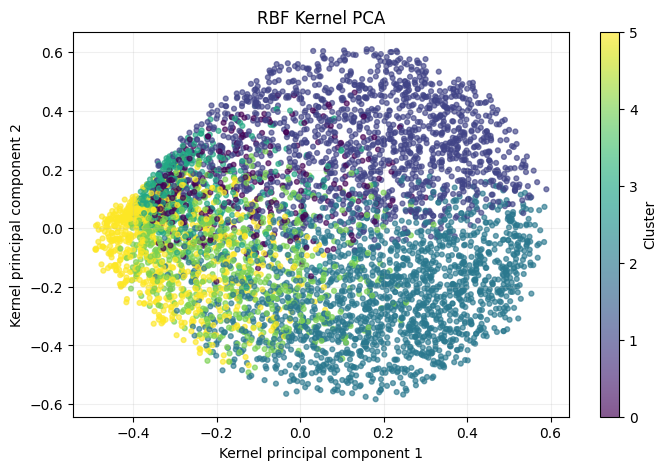

In [96]:
kpca_indices = np.random.default_rng(seed).choice(len(X_pca), size=min(5600, len(X_pca)), replace=False)

kpca = KernelPCA(n_components=2,kernel='rbf',gamma=1 / X_pca.shape[1],eigen_solver='arpack')
X_kpca = kpca.fit_transform(X_pca[kpca_indices])

plt.figure(figsize=(8,5))
scatter = plt.scatter( X_kpca[:, 0], X_kpca[:,1],c=final_labels[kpca_indices],s=12, alpha=0.65)
plt.xlabel('Kernel principal component 1')
plt.ylabel('Kernel principal component 2')
plt.title('RBF Kernel PCA')
plt.colorbar(scatter,label='Cluster')
plt.grid(alpha=0.2)
plt.show()

<div dir="rtl">

PCA معمولی فقط چرخش و تصویرسازی خطی انجام می‌ دهد در حالی که کرنل RBF روابط غیرخطی و محلی را نیز بازنمایی می‌ کند. در نمودار Kernel PCA ساختار خمیده تر و بعضی نواحی فشرده تر دیده می شوند اما هم پوشانی سه خوشه کاملا حذف نمی شود. بنابراین غیرخطی سازی نمایش را تغییر می دهد ولی نبود مرز تیز میان انواع موسیقی را به یک جدایی کامل تبدیل نمی کند. این بخش روی sub اجرا شده است چون ساخت ماتریس کرنل برای تمام حدود ۲۸ هزار آهنگ از نظر حافظه بسیار پرهزینه است.

</div>

<div dir="rtl">

# سؤال دوم: `PCA`، چهره‌های ویژه و طبقه‌بندی

این سؤال شامل پیاده‌سازی `PCA` روی داده `IRIS` و سپس استفاده از `PCA` و `LDA` برای داده چهره‌ها است.

</div>

<div dir="rtl">

## ۲.۱ پیاده‌سازی `PCA` از ابتدا روی `IRIS`

تابع `PCA` خود را از ابتدا پیاده‌سازی کنید. پیاده‌سازی باید شامل مرکز کردن داده، محاسبه ماتریس کوواریانس، استخراج مقادیر و بردارهای ویژه، مرتب‌سازی مولفه‌ها و تصویر کردن داده روی مولفه‌های اصلی باشد.

</div>

In [97]:
def my_pca(X, n_components):
    X = np.asarray(X, dtype=float)
    X_centered = X- X.mean(axis=0)
    eigenvalues, eigenvectors =np.linalg.eigh(np.cov(X_centered, rowvar=False))
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues =eigenvalues[order]
    eigenvectors = eigenvectors[:,order]
    components=eigenvectors[:,:n_components].T
    X_projected =X_centered @ components.T
    explained_variance = eigenvalues
    return X_projected, components, explained_variance

Shape of Projected Data: (150, 2)
Cumulative Explained Variance of the First Two Components: 0.9776852063187949


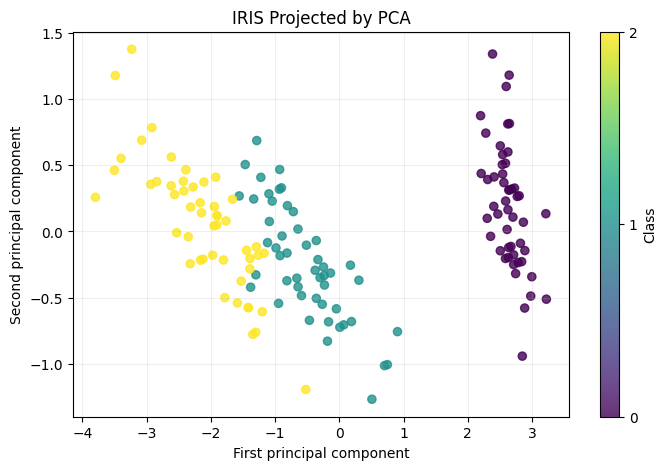

Explained Variance Ratio: [0.92461872 0.05306648]
Equivalence of Eigenvectors :
[[1. 0.]
 [0. 1.]]


In [98]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_iris_2d, components, explained_variance = my_pca(X_iris, n_components=2)
explained_variance_ratio_iris = explained_variance / explained_variance.sum()

print('Shape of Projected Data:', X_iris_2d.shape)
print('Cumulative Explained Variance of the First Two Components:', explained_variance_ratio_iris[:2].sum())

plt.figure(figsize=(8,5))
scatter = plt.scatter(X_iris_2d[:,0], X_iris_2d[:, 1],c=y_iris, s=35,alpha=0.8)
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('IRIS Projected by PCA')
plt.colorbar(scatter, ticks=[0, 1, 2], label='Class')
plt.grid(alpha=0.2)
plt.show()
 
PCA_iris = PCA(n_components=2).fit(X_iris)
print('Explained Variance Ratio:',PCA_iris.explained_variance_ratio_)
print('Equivalence of Eigenvectors :')
print(np.abs(components @ PCA_iris.components_.T).round(6))

<div dir="rtl">

### تحلیل نتیجه `PCA` روی `IRIS`

آیا دو مولفه اول برای جداسازی کلاس‌ها کافی به نظر می‌رسند؟ پاسخ را با توجه به نمودار بنویسید.

دو مؤلفه ی اول حدود **97.77٪** واریانس کل را حفظ می‌ کنند. کلاس setosa در نمودار به وضوح از دو کلاس دیگر جدا شده است اما versicolor و virginica در بخشی از فضا هم پوشانی دارند. بنابراین دو مؤلفه برای نمایش و درک ساختار کلی داده بسیار مناسب اند ولی برای جداسازی کاملا بدون خطای هر سه کلاس تضمین کافی ندارند. مقادیر و بردارهای ویژه نیز با خروجی sklearn با تفاوت علامت بردار ویژه هم خوانی دارند و علامت بردار ویژه اثری بر زیرفضای PCA ندارد.

</div>

<div dir="rtl">

## ۲.۲ مفهوم چهره‌های ویژه

مفهوم `eigenfaces` را توضیح دهید و ارتباط آن را با `PCA` بیان کنید.

eigenfaces بردارهای ویژه ی اصلی ماتریس کوواریانس تصاویر چهره اند. برای ساخت آن ها ابتدا هر تصویر خاکستری به یک بردار بلند تبدیل می شود سپس میانگین چهره از همه تصاویر کم شده و PCA جهت هایی را پیدا می کند که بیشترین تغییرات مجموعه را توضیح می دهند.

هر چهره ی واقعی را می توان تقریبا به صورت میانگین چهره + ترکیب خطی چند eigenface نوشت. ضرایب این ترکیب ویژگی های فشرده ی تصویر هستند. eigenface ها معمولا شبیه یک انسان واقعی نیستند زیرا یک تصویر فیزیکی مستقل نیستند و الگوهای مثبت و منفی تغییر نسبت به میانگین اند مانند جهت صورت و محدوده چشم ها و مو و خطوط کلی چهره. به همین دلیل نمایش چند eigenface به صورت تصویر کمک می‌ کند بفهمیم PCA چه نوع تغییراتی را از داده یاد گرفته است.

</div>

<div dir="rtl">

## ۲.۳ خواندن مجموعه‌داده چهره‌ها و ساخت داده آموزش و آزمون

مجموعه‌داده شامل ۴۰ پوشه است و در هر پوشه ۱۰ تصویر از یک فرد وجود دارد. برای هر فرد، پنج تصویر اول را برای آموزش و پنج تصویر آخر را برای آزمون استفاده کنید و آرایه‌های زیر را بسازید:

`train_X`, `test_X`, `train_y`, `test_y`

</div>

In [99]:
import os
import cv2

faces_dir = 'FacesDataset1/ORL'
train_X = []
test_X = []
train_y = []
test_y = []

image_shape = None
for person_id in range(1, 41):
    person_dir = os.path.join(faces_dir, f's{person_id}')
    for image_id in range(1, 11):
        image_path =os.path.join(person_dir, f'{image_id}.bmp')
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        image_shape =image.shape
        flattened_image = image.astype(np.float64).ravel() / 255.0
        if image_id<= 5:
            train_X.append(flattened_image)
            train_y.append(person_id)
        else:
            test_X.append(flattened_image)
            test_y.append(person_id)

In [100]:
train_X = np.asarray(train_X, dtype=np.float64)
test_X = np.asarray(test_X, dtype=np.float64)
train_y = np.asarray(train_y, dtype=int)
test_y = np.asarray(test_y, dtype=int)

print(train_X.shape, test_X.shape, train_y.shape, test_y.shape)

(200, 2304) (200, 2304) (200,) (200,)


<div dir="rtl">

### توضیح ساخت ماتریس‌ها

هر سطر در ماتریس داده نشان‌دهنده چیست؟ هر سطر در train_X یا test_X یک تصویر کامل از یک چهره است که از ماتریس 48×48 به برداری با 2304 مؤلفه تبدیل شده است.

هر ستون در ماتریس داده نشان‌دهنده چیست؟ هر ستون شدت خاکستری یک مکان پیکسلی ثابت را در تمام تصاویر نشان می دهد. برای مثال ستون اول همیشه پیکسل گوشه ی بالا-چپ است.

</div>

<div dir="rtl">

## ۲.۴ اجرای `PCA` روی تصاویر چهره

`PCA` را فقط روی داده آموزشی fit کنید و سپس همان تبدیل را روی داده آزمون اعمال کنید. تعداد مولفه‌ها را در محدوده مناسب، مثلا بین ۴۰ تا ۵۰، انتخاب کنید. حداقل پنج چهره ویژه اول را به شکل تصویر نمایش دهید.

</div>

In [101]:
from sklearn.decomposition import PCA

n_components_faces = 40

pca_faces = PCA(n_components=n_components_faces,svd_solver='randomized',random_state=seed)
train_X_pca = pca_faces.fit_transform(train_X)
test_X_pca = pca_faces.transform(test_X)

print('train_X_pca:', train_X_pca.shape)
print('test_X_pca :', test_X_pca.shape)

train_X_pca: (200, 40)
test_X_pca : (200, 40)


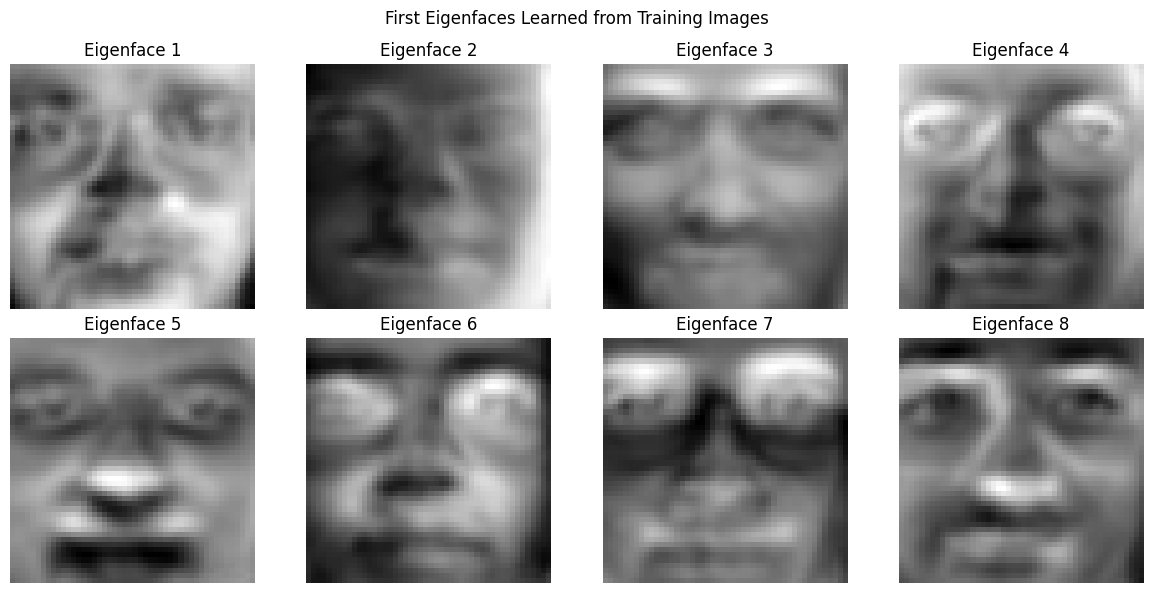

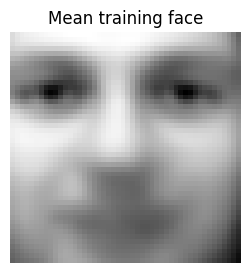

In [102]:
fig,axes = plt.subplots(2, 4, figsize=(12, 6))
for id,ax in enumerate(axes.ravel()):
    eigenface = pca_faces.components_[id].reshape(image_shape)
    ax.imshow(eigenface,cmap='gray')
    ax.set_title(f'Eigenface {id +1}')
    ax.axis('off')
plt.suptitle('First Eigenfaces Learned from Training Images')
plt.tight_layout()
plt.show()
plt.figure(figsize=(3,3))
plt.imshow(pca_faces.mean_.reshape(image_shape), cmap='gray')
plt.title('Mean training face')
plt.axis('off')
plt.show()

<div dir="rtl">

### توضیح چهره‌های ویژه

چرا این تصاویر شبیه چهره معمولی نیستند، اما الگوهای مهمی از تغییرات چهره‌ها را نشان می‌دهند؟
این تصاویر چهره ی یک فرد نیستند بلکه جهت های تغییر نسبت به چهره ی میانگین اند. مقدار هر پیکسل در یک مولفه می تواند مثبت یا منفی باشد بنابراین نواحی روشن و تیره نشان می دهند با افزایش ضریب آن مولفه کدام قسمت ها نسبت به میانگین روشن تر یا تیره تر می‌ شوند. مولفه های اول معمولا تغییرات سراسری نور و شکل کلی سر را نشان می‌ دهند و مولفه های بعدی بیشتر به چشم هاو مو و حالت صورت حساس اند. همین الگوها برای نمایش فشرده و تشخیص هویت مفیدند هرچند خودشان تصویر طبیعی به نظر نمی‌ رسند.

</div>

<div dir="rtl">

## ۲.۵ آموزش طبقه‌بند `LDA`

یک طبقه‌بند `LDA` را روی داده‌های تبدیل‌شده با `PCA` آموزش دهید. دقت و ماتریس درهم‌ریختگی را روی داده آزمون گزارش کنید.

</div>

Test accuracy with 40 PCA components: 0.935


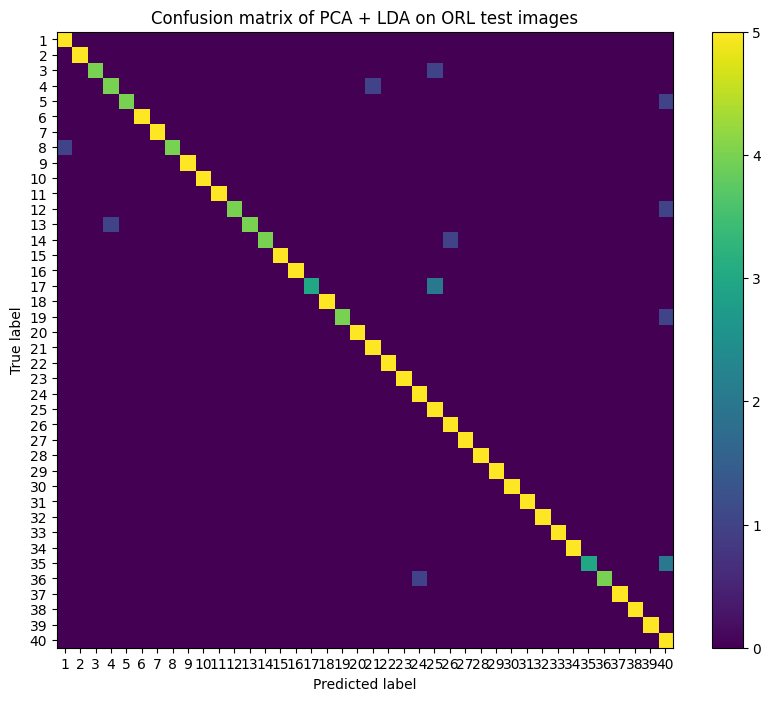

,True_Person,predicted,count
0,17,25,2
1,35,40,2
2,3,25,1
3,4,21,1
4,5,40,1
5,8,1,1
6,12,40,1
7,13,4,1
8,14,26,1
9,19,40,1


In [103]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

lda = LDA(solver='svd')
lda.fit(train_X_pca,train_y)
test_predictions= lda.predict(test_X_pca)
face_accuracy = accuracy_score(test_y, test_predictions)
face_Confusion_m =confusion_matrix(test_y, test_predictions, labels=np.arange(1, 41))
print(f'Test accuracy with {n_components_faces} PCA components: {face_accuracy:.3f}')

fig, ax = plt.subplots(figsize=(10,8))
ConfusionMatrixDisplay(confusion_matrix=face_Confusion_m,display_labels=np.arange(1,41)).plot(ax=ax, include_values=False, colorbar=True)
ax.set_title('Confusion matrix of PCA + LDA on ORL test images')
plt.show()
confusion_pairs = []
for i in range (40):
    for j in range(40):
        if i !=j and face_Confusion_m[i,j] > 0:
            confusion_pairs.append({'True_Person': i+ 1,'predicted': j +1,'count': int(face_Confusion_m[i, j])})
display((pd.DataFrame(confusion_pairs).sort_values(['count','True_Person'], ascending=[False, True]).reset_index(drop=True)).head(12))

<div dir="rtl">

### تحلیل طبقه‌بندی

کدام افراد بیشتر با یکدیگر اشتباه شده‌اند؟ دلیل احتمالی چیست؟
با ۴۰ مولفه ی PCA دقت آزمون **93.5٪** است یعنی از ۲۰۰ تصویر آزمون ۱۸۷ تصویر درست شناسایی شده اند. پرتکرارترین خطاها : فرد ۳۵ به جای فرد ۴۰ در دو تصویر و فرد ۱۷ به‌ جای فرد ۲۵ در دو تصویر و چند خطای تک‌ نمونه ای نیز وجود دارد.

دلیل احتمالی این اشتباه ها شباهت در جهت صورت و حالت چهره و عینک یا الگوی نور و سایه است. از هر فرد فقط پنج تصویر برای آموزش وجود دارد بنابراین اگر تصاویر آزمون حالت یا روشنایی متفاوتی داشته باشند بردار ویژگی ممکن است به فردی با ظاهر مشابه نزدیک‌تر شود. ماتریس درهم ریختگی غالبا قطری است پس مدل در بیشتر کلاس ها عملکرد خوبی دارد.

</div>

<div dir="rtl">

## ۲.۶ بررسی اثر تعداد مولفه‌های `PCA`

فرایند استخراج ویژگی با `PCA` و طبقه‌بندی با `LDA` را برای چند مقدار مختلف تعداد مولفه‌ها در بازه ۴۰ تا ۱۰۰ تکرار کنید. دقت آزمون را ذخیره و نمودار دقت بر حسب تعداد مولفه‌ها را رسم کنید.

</div>

In [106]:
pca_dimensions = [40,50, 60, 70,80, 90, 100]
accuracies = []
variances_faces = []

for i in pca_dimensions:
    pca_temp = PCA(n_components=i,svd_solver='randomized',random_state=seed)
    train_temp= pca_temp.fit_transform(train_X)
    test_temp = pca_temp.transform(test_X)
    lda_temp = LDA(solver='svd')
    lda_temp.fit(train_temp,train_y)
    predictions_temp =lda_temp.predict(test_temp)
    accuracies.append(accuracy_score(test_y, predictions_temp))
    variances_faces.append(pca_temp.explained_variance_ratio_.sum())

pca_table = pd.DataFrame({'n_components': pca_dimensions,'test_accuracy': accuracies,'cumulative_explained_variance': variances_faces})
display(pca_table.round(4))

,n_components,test_accuracy,cumulative_explained_variance
0,40,0.935,0.9350
1,50,0.925,0.9525
2,60,0.910,0.9648
3,70,0.915,0.9735
4,80,0.925,0.9798
5,90,0.915,0.9845
6,100,0.900,0.9882


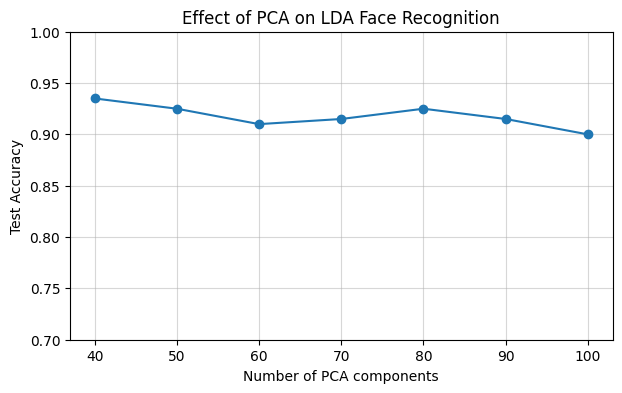

Best Number of Components among Tested Values: 40
Best accuracy: 0.935


In [112]:
plt.figure(figsize=(7,4))
plt.plot(pca_dimensions, accuracies, marker='o')
plt.xlabel('Number of PCA components')
plt.ylabel('Test Accuracy')
plt.title('Effect of PCA on LDA Face Recognition')
plt.xticks(pca_dimensions)
plt.ylim(0.7,1)
plt.grid(alpha=0.5)
plt.show()

print('Best Number of Components among Tested Values:', pca_dimensions[int(np.argmax(accuracies))])
print('Best accuracy:', accuracies[int(np.argmax(accuracies))])

<div dir="rtl">

### جمع‌بندی سؤال دوم

در مقادیر آزموده شده، 40 مولفه با دقت **93.5٪** بهترین نتیجه را داده است و حدود 93.5٪ واریانس تصاویر آموزشی را حفظ می‌ کند. ۵۰ مولفه نتیجه ی نزدیک 93٪ دارد اما با افزایش بعد به 60 تا 100 دقت روند افزایشی ندارد و در 100 مولفه به حدود 88.5٪ کاهش می‌ یابد. بنابراین برای این تقسیم داده حدود 40 تا 50 ویژگی PCA کافی است.

افزودن مولفه های کم‌اهمیت الزاما مفید نیست. این مولفه ها ممکن است نویز و تغییرات نور یا جزئیات خاص تصاویر آموزشی را وارد کنند. در نتیجه LDA با داده ی محدود دچار بیش‌ برازش می‌ شود. انتخاب 40 مولفه هم فشرده سازی شدیدی نسبت به 2304 پیکسل ایجاد می‌ کند و هم بهترین دقت مشاهده شده را حفظ می‌ کند.

</div>

<div dir="rtl">

# چک‌لیست نهایی

قبل از تحویل، مطمئن شوید موارد زیر در نوت‌بوک وجود دارد:

1. اجرای کامل سلول‌ها بدون خطا؛
2. توضیح دلیل انتخاب ویژگی‌ها در سؤال اسپاتیفای؛
3. پیاده‌سازی استانداردسازی از ابتدا؛
4. پیاده‌سازی `K-Means` از ابتدا؛
5. نمودارهای `Silhouette` و `Davies-Bouldin`؛
6. انتخاب و تحلیل مقدار نهایی `k`؛
7. پیاده‌سازی `PCA` از ابتدا برای `IRIS`؛
8. ساخت درست داده آموزش و آزمون برای تصاویر چهره؛
9. نمایش چند چهره ویژه؛
10. آموزش `LDA` و تحلیل دقت؛
11. بررسی اثر تعداد مولفه‌های `PCA`؛
12. توضیح‌های کوتاه بر اساس خروجی واقعی خودتان.

</div>